# Lilylet M3 distillation model validation

Validates `LilyletM3Encoder` / `LilyletM3EncoderLoss` (the ABC→Lilylet M3
distillation student): loads the `LilyletM3Distill` dataset and the model, runs a
forward pass, checks the cosine-regression loss & cos metric, verifies the
long-sequence (>512 patch) chunk-and-pool path, and overfits one batch to confirm
the loss decreases / cosine rises toward the frozen ABC teacher target.

Config: `configs/lilylet-m3-distill.yaml`  ·  Data: `~/data/lilylet/m3/notagenx-from-abc.pt`


In [1]:
from pathlib import Path
import sys

REPO_ROOT = next(p for p in [Path.cwd(), *Path.cwd().parents] if (p / 'starry').is_dir())
if str(REPO_ROOT) not in sys.path:
    sys.path.insert(0, str(REPO_ROOT))

import torch
from starry.utils.config import Configuration
from starry.utils.dataset_factory import loadDataset
from starry.utils.model_factory import loadModel

CONFIG = str(REPO_ROOT / 'configs' / 'lilylet-m3-distill.yaml')
print('repo:', REPO_ROOT)
print('config:', CONFIG)


repo: /home/camus/work/deep-starry
config: /home/camus/work/deep-starry/configs/lilylet-m3-distill.yaml


In [2]:
config = Configuration.createOrLoad(CONFIG, volatile=True)
# config.data.root is already an absolute path to the pooled artifact, so data_dir
# is irrelevant (os.path.join ignores it for an absolute root).
config['data.batch_size'] = 4
config['trainer.device'] = 'cpu'

train, val = loadDataset(config, data_dir='.', device='cpu')
print('train items:', len(train.dataset), 'val items:', len(val.dataset))

batch = next(iter(train))
print('batch keys:', list(batch.keys()))
print('input_patches  :', tuple(batch['input_patches'].shape), batch['input_patches'].dtype)
print('input_masks    :', tuple(batch['input_masks'].shape))
print('target_embedding:', tuple(batch['target_embedding'].shape), batch['target_embedding'].dtype)


train items: 194 val items: 21
batch keys: ['input_patches', 'input_masks', 'target_embedding']
input_patches  : (4, 277, 64) torch.int64
input_masks    : (4, 277)
target_embedding: (4, 768) torch.float32


In [3]:
# Inference model (deducer) and Loss model (training wrapper)
deducer = loadModel(config['model'])
model = loadModel(config['model'], postfix='Loss')

n_params = sum(p.numel() for p in model.deducer.parameters())
print('LilyletM3Encoder params: %.2fM' % (n_params / 2**20))
print('num_classes     :', model.deducer.num_classes)
print('hidden_size     :', model.deducer.hidden_size)
print('encoder layers  :', model.deducer.encoder.base.config.num_hidden_layers)
print('position cap     :', model.deducer.encoder.config.max_position_embeddings)
print('projection head :', model.deducer.proj is not None)


LilyletM3Encoder params: 94.62M
num_classes     : 256
hidden_size     : 768
encoder layers  : 12
position cap     : 512
projection head : True


In [4]:
# Single forward pass: loss (scalar Tensor) + metric (dict with 'cos')
model.train()
loss, metric = model(batch)
print('loss  :', loss.item())
print('metric:', metric)
assert loss.requires_grad and loss.dim() == 0

# deducer alone returns the pooled [B, hidden] embedding
model.eval()
with torch.no_grad():
    pred = model.deducer(batch['input_patches'], batch['input_masks'])
print('pooled embedding:', tuple(pred.shape), pred.dtype)
print('target embedding:', tuple(batch['target_embedding'].shape))
assert pred.shape == batch['target_embedding'].shape


loss  : 0.9933561682701111
metric: {'cos': 0.006643821485340595}


pooled embedding: (4, 768) torch.float32
target embedding: (4, 768)


## Long-sequence (>512 patches) chunk-and-pool path

52/215 samples exceed the 512 position cap. The student segments these into ≤512
chunks, masked-mean-pools each, and length-weighted-averages — mirroring the ABC
teacher's `extract_clamp2` aggregation. Verify a long sample runs and that the
chunked pooling equals a manual two-chunk computation.

In [5]:
# find a validation/train item longer than the position cap
cap = model.deducer.encoder.config.max_position_embeddings
store = train.dataset.store
long_idx = next((i for i in range(len(store)) if store.get(i)['patches'].shape[0] > cap), None)
print('position cap:', cap, '| first item with >cap patches:', long_idx)

if long_idx is not None:
    item = store.get(long_idx)
    p = item['patches'].long().unsqueeze(0)              # [1, T, 64]
    m = torch.ones(1, p.shape[1], dtype=torch.long)
    print('long sample patches:', tuple(p.shape))
    model.eval()
    with torch.no_grad():
        out = model.deducer(p, m)
    print('pooled output:', tuple(out.shape), '| finite:', bool(torch.isfinite(out).all()))
    assert out.shape == (1, model.deducer.hidden_size)
else:
    print('no >cap sample in this split; chunk path not exercised here')


position cap: 512 | first item with >cap patches: 27
long sample patches: (1, 1663, 64)


pooled output: (1, 768) | finite: True


## Per-sample cosine to the teacher target

For an untrained model the cosine is ~0; after training (or overfitting) it should
rise toward 1. Show the spread over the current batch.

In [6]:
model.eval()
with torch.no_grad():
    pred = model.deducer(batch['input_patches'], batch['input_masks'])
    cos = torch.nn.functional.cosine_similarity(pred, batch['target_embedding'], dim=-1)
print('per-sample cosine to teacher:', [round(c, 4) for c in cos.tolist()])
print('mean cosine:', round(cos.mean().item(), 4), '(untrained ~0)')


per-sample cosine to teacher: [-0.0238, 0.0364, 0.0009, 0.0225]
mean cosine: 0.009 (untrained ~0)


## Overfit one batch

A few steps on a single batch should drive the loss down and the cosine up — a
quick sanity check that the distillation objective is wired correctly.

In [7]:
model.train()
opt = torch.optim.Adam(model.parameters(), lr=1e-3)
history = []
for step in range(30):
    opt.zero_grad()
    loss, metric = model(batch)
    loss.backward()
    opt.step()
    history.append((loss.item(), metric['cos']))
    if step % 5 == 0 or step == 29:
        print(f'step {step:02d}  loss={loss.item():.4f}  cos={metric["cos"]:.4f}')

print('\nloss start -> end:', round(history[0][0], 4), '->', round(history[-1][0], 4))
print('cos  start -> end:', round(history[0][1], 4), '->', round(history[-1][1], 4))
assert history[-1][0] < history[0][0], 'loss did not decrease'
assert history[-1][1] > history[0][1], 'cosine did not increase'


step 00  loss=0.9912  cos=0.0088


step 05  loss=0.1773  cos=0.8227


step 10  loss=0.1480  cos=0.8520


step 15  loss=0.1429  cos=0.8571


step 20  loss=0.1398  cos=0.8602


step 25  loss=0.1386  cos=0.8614


step 29  loss=0.1381  cos=0.8619

loss start -> end: 0.9912 -> 0.1381
cos  start -> end: 0.0088 -> 0.8619


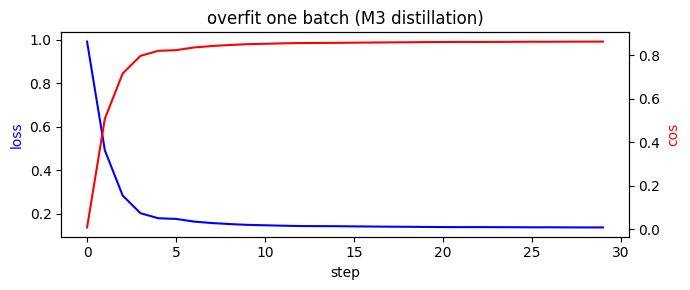

In [8]:
# Optional: loss / cosine curve
# Force the inline backend: .env.local sets MPLBACKEND=TkAgg (a GUI backend),
# which renders nothing under headless/nbconvert execution.
%matplotlib inline
import matplotlib
matplotlib.use('module://matplotlib_inline.backend_inline', force=True)
import matplotlib.pyplot as plt

losses = [h[0] for h in history]
coss = [h[1] for h in history]
fig, ax1 = plt.subplots(figsize=(7, 3))
ax1.plot(losses, 'b-', label='loss'); ax1.set_ylabel('loss', color='b'); ax1.set_xlabel('step')
ax2 = ax1.twinx(); ax2.plot(coss, 'r-', label='cos'); ax2.set_ylabel('cos', color='r')
plt.title('overfit one batch (M3 distillation)'); plt.tight_layout(); plt.show()


## (Optional) load a trained checkpoint

If a training run has produced checkpoints under
`~/data/training/lilylet-m3-distill/`, load the best one into the deducer and
report the batch cosine — should be well above the untrained ~0.

In [9]:
import glob, os

ckpts = sorted(glob.glob(str(Path.home() / 'data/training/lilylet-m3-distill/*/model_*.chkpt')))
if ckpts:
    # pick the lowest-loss checkpoint by the loss encoded in the filename
    best = min(ckpts, key=lambda p: float(p.split('loss_')[-1].replace('.chkpt', '')))
    print('loading:', os.path.basename(best))
    state = torch.load(best, map_location='cpu', weights_only=False)
    sd = state['model'] if isinstance(state, dict) and 'model' in state else state
    fresh = loadModel(config['model'])
    fresh.load_state_dict(sd)
    fresh.eval()
    with torch.no_grad():
        pred = fresh(batch['input_patches'], batch['input_masks'])
        cos = torch.nn.functional.cosine_similarity(pred, batch['target_embedding'], dim=-1)
    print('trained mean cosine on batch:', round(cos.mean().item(), 4))
else:
    print('no trained checkpoints found; skip (run train.py configs/lilylet-m3-distill.yaml first)')


loading: model_05_loss_2.578e-01.chkpt


trained mean cosine on batch: 0.6926
